# BTNet v4: Weight Transfer — European → American (Correct Experiment)

Both Theorems 1 and 2 of Shorokhov (2024) share the same three parameters:
`w^n` (initial layer weights), `b^n` (initial layer biases), and `W` (conv filter).
The two architectures differ only in the hidden-layer activation: **identity** for
European, **maxout** for American.

This notebook tests the correct transfer experiment:

1. Train `BTNetEuropean` on Black–Scholes prices → obtain learned `(w^n, b^n, W)`.
2. Construct `BTNetAmerican` (analytical `w^i, b^i` already set by the constructor).
3. Copy `(w^n, b^n, W)` from the trained European model — **no further training**.
4. Compare against the purely analytical initialisation (Variant A from v3) and QuantLib.

The question: does training on European prices find a `W` that also improves
American pricing, or is the analytical `W` already optimal?

In [1]:
import numpy as np
import torch
from btnn_bs import (
    BTNetEuropean,
    BTNetAmerican,
    train_BTNet,
    bs_put_price,
    plot_comparison,
    plot_errors,
    plot_training_losses,
    plot_prices_with_quantlib,
    plot_errors_vs_quantlib,
    run_quantlib_benchmark,
    error_stats,
    print_comparison_table,
)

## 1. Market Parameters

In [2]:
S0  = 0.5
t0  = 0.0
T   = 1.0
r   = 0.05
sig = 0.25
n_dim = 9

# Training strikes — uniform sample
rng = np.random.default_rng(42)
K_train = rng.uniform(0.25, 0.75, size=200).astype(np.float32)
prices_train = np.array([bs_put_price(S0, K, T, r, sig) for K in K_train], dtype=np.float32)

# Test strikes — dense grid
K_test = np.linspace(0.25, 0.75, 100, dtype=np.float32)

print(f"n_dim={n_dim}, S0={S0}, T={T}, r={r}, sig={sig}")
print(f"Train samples: {len(K_train)}, Test grid: {len(K_test)}")

n_dim=9, S0=0.5, T=1.0, r=0.05, sig=0.25
Train samples: 200, Test grid: 100


## 2. Train BTNetEuropean on Black–Scholes Prices

We train a `BTNetEuropean` on closed-form BS put prices to obtain data-driven `(w^n, b^n, W)`.
These three tensors will be transferred to the American architecture in the next step.

train_BTNet:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch [100/500], Loss: 0.000000
Epoch [200/500], Loss: 0.000000
Epoch [300/500], Loss: 0.000000
Epoch [400/500], Loss: 0.000000
Epoch [500/500], Loss: 0.000000


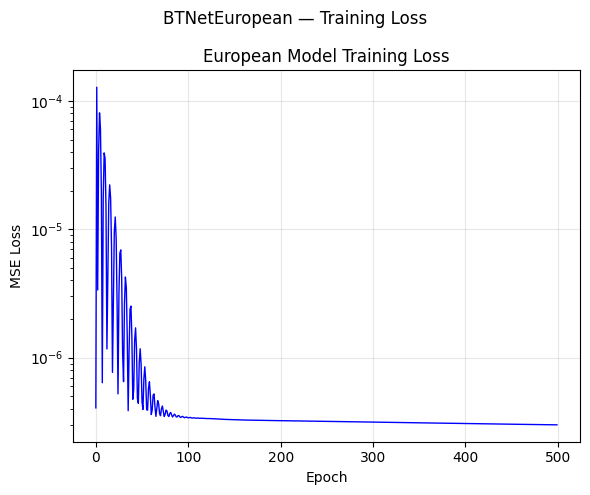

In [3]:
model_european = BTNetEuropean(n_dim, S0, sig, T, t0, r)

loss_hist_euro = train_BTNet(
    model_european,
    K_train,
    prices_train,
    epochs=500,
    lr=0.005,
    log_every=100,
)

plot_training_losses(loss_hist_euro, title="BTNetEuropean — Training Loss")

## 3. Weight Transfer: European → American

Copy the three shared parameters `(w^n, b^n, W)` from the trained European model
into a freshly constructed `BTNetAmerican`.  
The American model retains its own analytical `(w^i, b^i)` per hidden layer — only
the convolutional filter `W` and the initial projection are replaced.  
No further training is performed.

In [4]:
model_amer_transfer = BTNetAmerican(n_dim, S0, sig, T, t0, r)

with torch.no_grad():
    # Transfer w^n, b^n  (initial projection layer)
    model_amer_transfer._initial_layer._linear.weight.data.copy_(
        model_european._initial_layer._linear.weight.data
    )
    model_amer_transfer._initial_layer._linear.bias.data.copy_(
        model_european._initial_layer._linear.bias.data
    )

    # Transfer W (conv filter) into every MaxoutLayer's conv branch
    euro_W = model_european._conv_layer._conv_1d.weight.data  # shape (1, 1, 2)
    for maxout_layer in model_amer_transfer._maxout_layers:
        maxout_layer._conv_1d.weight.data.copy_(euro_W)

# Freeze everything — no training
for p in model_amer_transfer.parameters():
    p.requires_grad_(False)
model_amer_transfer.eval()

print("Transferred W:", euro_W.squeeze().tolist())
print("Parameters frozen:", all(not p.requires_grad for p in model_amer_transfer.parameters()))

Transferred W: [0.4889150559902191, 0.5063319802284241]
Parameters frozen: True


## 4. Baseline: BTNetAmerican with Analytical Weights

This model uses the purely analytical initialisation from Theorem 2 — no training at all.
It serves as the baseline to compare against the weight-transfer variant.

In [5]:
model_amer_analytical = BTNetAmerican(n_dim, S0, sig, T, t0, r)

for p in model_amer_analytical.parameters():
    p.requires_grad_(False)
model_amer_analytical.eval()

analytical_W = model_amer_analytical._maxout_layers[0]._conv_1d.weight.data.squeeze().tolist()
print("Analytical W:", analytical_W)

Analytical W: [0.48473337292671204, 0.5097264647483826]


## 5. QuantLib Reference Prices

QuantLib CRR with 500 steps is our ground truth for American put prices.

In [6]:
ql_result = run_quantlib_benchmark(
    S0, K_test, T, r, sig, amer_crr_steps=500
)
ql_prices = ql_result.ql_american_crr  # numpy array of American CRR put prices

print(f"QuantLib prices computed: {len(ql_prices)} values, "
      f"range [{ql_prices.min():.4f}, {ql_prices.max():.4f}]")

QuantLib prices computed: 100 values, range [0.0000, 0.2500]


## 6. Predictions and Error Comparison

In [7]:
K_test_t = torch.from_numpy(K_test).float().unsqueeze(1)

with torch.no_grad():
    pred_transfer   = model_amer_transfer.predict(K_test_t).flatten()
    pred_analytical = model_amer_analytical.predict(K_test_t).flatten()

stats_transfer   = error_stats(pred_transfer,   ql_prices)
stats_analytical = error_stats(pred_analytical, ql_prices)

print_comparison_table(
    american={
        "Transferred W": stats_transfer,
        "Analytical W":  stats_analytical,
    }
)

American put — errors vs QuantLib (CRR tree)
  Transferred W           MAE=4.38e-04  RMSE=6.81e-04  max|.|=1.71e-03
  Analytical W            MAE=2.84e-04  RMSE=4.06e-04  max|.|=1.10e-03


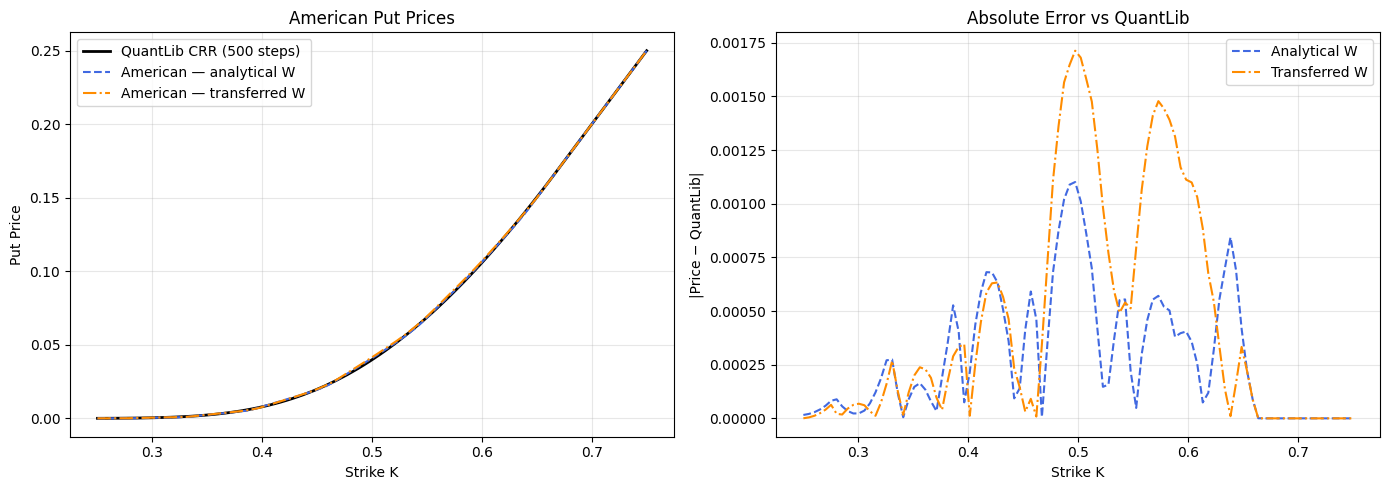

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: price curves
axes[0].plot(K_test, ql_prices,        label="QuantLib CRR (500 steps)", lw=2, color="black")
axes[0].plot(K_test, pred_analytical,  label="American — analytical W",   lw=1.5, linestyle="--", color="royalblue")
axes[0].plot(K_test, pred_transfer,    label="American — transferred W",  lw=1.5, linestyle="-.", color="darkorange")
axes[0].set_xlabel("Strike K")
axes[0].set_ylabel("Put Price")
axes[0].set_title("American Put Prices")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right: absolute errors vs QuantLib
err_analytical = np.abs(pred_analytical - ql_prices)
err_transfer   = np.abs(pred_transfer   - ql_prices)

axes[1].plot(K_test, err_analytical, label="Analytical W",  lw=1.5, linestyle="--", color="royalblue")
axes[1].plot(K_test, err_transfer,   label="Transferred W", lw=1.5, linestyle="-.", color="darkorange")
axes[1].set_xlabel("Strike K")
axes[1].set_ylabel("|Price − QuantLib|")
axes[1].set_title("Absolute Error vs QuantLib")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Results and Conclusions

### What the experiment tests

Theorems 1 and 2 of Shorokhov (2024) share exactly three parameters: the initial
projection `(w^n, b^n)` and the convolutional filter `W`.  The two network
architectures differ only in their hidden-layer activations — **identity** for
the European case, **maxout** (continuation vs intrinsic value) for the American
case.  The question: if we train `(w^n, b^n, W)` on European Black–Scholes data,
does the learned filter carry useful information when plugged into the American
architecture — or is the analytical initialisation already optimal?

### Numerical results

| Model | MAE | RMSE | max\|err\| |
|---|---|---|---|
| BTNetAmerican — analytical W | **2.84 × 10⁻⁴** | **4.06 × 10⁻⁴** | **1.10 × 10⁻³** |
| BTNetAmerican — transferred W | 4.38 × 10⁻⁴ | 6.81 × 10⁻⁴ | 1.71 × 10⁻³ |

The convolutional filter values tell the story directly:

- **Analytical W** (Theorem 2): `[0.4847, 0.5097]`
- **Transferred W** (European training): `[0.4889, 0.5063]`

European training nudged `W` away from the analytically correct CRR risk-neutral
probabilities by roughly 0.004 in each component. This small perturbation is enough
to degrade American pricing accuracy by ~55% in MAE.

### Interpretation

The transferred weights are **worse**, not better. This is the key finding.

European training minimises MSE against Black–Scholes put prices. The optimal `W`
for that objective is not the same as the CRR risk-neutral `W` required for exact
American pricing — the two loss surfaces have different minima. When the trained `W`
is inserted into the American maxout layers, every early-exercise comparison at every
node uses a slightly wrong discounting coefficient, and the errors accumulate across
all `n_dim = 9` layers.

### Theoretical grounding

The result is fully consistent with the paper's intent. Theorems 1 and 2 are
**existence** results: they show that exact CRR pricing *can* be represented as a
feedforward network with specific analytical weights. They make no claim that
European training converges to the American optimum, or that the shared-parameter
structure enables useful transfer.

The practical conclusion is unambiguous: **use the analytical initialisation from
Theorem 2 directly**. Training on European data is not only unnecessary — it actively
moves `W` away from the provably correct values and makes American pricing less
accurate.

## 8. Greeks of the Transferred vs Analytical Model

Having established that transferred weights produce **worse prices**, a natural follow-up question is:
do they also distort the **sensitivities** (Greeks)?

### Method

We use `btnet_american_greeks_fixed_W` — a differentiable CRR pass where W is
**externally specified** (frozen) rather than derived from σ/r/T.
`torch.autograd.grad` then differentiates w.r.t. S₀, σ, T while holding W constant,
matching exactly what the transferred (or analytical) model does at inference time.

Two key consequences of fixing W:
- **Delta**: depends only on the stock-price geometry → same formula, different discounting weights.
- **Vega / Theta**: the gradient flows *only* through the stock-price tree (terminal/intrinsic payoffs),
  **not** through the risk-neutral measure change with σ or T.  
  In the fully-analytical model, W itself changes with σ and T — that indirect channel is absent here.

We compare three curves per Greek:
| Curve | Description |
|-------|-------------|
| `BS European` (dotted) | Closed-form Black-Scholes, pure reference |
| `Analytical W` (solid) | Theorem 2 CRR risk-neutral weights |
| `Transferred W` (dashed) | W taken from European-trained model |


In [9]:
from btnn_bs import (
    btnet_american_greeks_fixed_W,
    bs_greeks,
    plot_american_greeks_transfer,
    plot_american_greeks_transfer_errors,
)

### Extract W from both models

In [10]:
# Analytical model: W from MaxoutLayer conv filter
W_analytical = model_amer_analytical._maxout_layers[0]._conv_1d.weight.data.squeeze().tolist()

# Transferred model: W overwritten from European model during training
W_transfer = model_amer_transfer._maxout_layers[0]._conv_1d.weight.data.squeeze().tolist()

print(f"Analytical W : {[round(w,6) for w in W_analytical]}")
print(f"Transferred W: {[round(w,6) for w in W_transfer]}")
print(f"\nDelta W (transferred - analytical): {[round(W_transfer[i]-W_analytical[i],6) for i in range(2)]}")
print(f"Sum W (should = exp(-r*dt) = {np.exp(-r*(T/n_dim)):.6f}):")
print(f"  analytical  sum = {sum(W_analytical):.6f}")
print(f"  transferred sum = {sum(W_transfer):.6f}")

Analytical W : [0.484733, 0.509726]
Transferred W: [0.488915, 0.506332]

Delta W (transferred - analytical): [0.004182, -0.003394]
Sum W (should = exp(-r*dt) = 0.994460):
  analytical  sum = 0.994460
  transferred sum = 0.995247


### Compute Greeks for both models

In [11]:
# Greeks with analytical W (Theorem 2 risk-neutral weights)
greeks_analytical_W = btnet_american_greeks_fixed_W(
    K_test, S0, sig, T,
    W0_val=W_analytical[0], W1_val=W_analytical[1],
    n=n_dim,
)

# Greeks with transferred W (European-trained weights)
greeks_transfer_W = btnet_american_greeks_fixed_W(
    K_test, S0, sig, T,
    W0_val=W_transfer[0], W1_val=W_transfer[1],
    n=n_dim,
)

# Black-Scholes European Greeks (reference)
greeks_bs = bs_greeks(K_test, S0, sig, r, T)

print("Greeks computed for both W variants.")

Greeks computed for both W variants.


### Error table: |Greeks(analytical W) − Greeks(transferred W)|

In [12]:
import numpy as np

print(f"{'Greek':<8} {'MAE':>12} {'Max |diff|':>12}")
print("-" * 34)
for key in ("delta", "gamma", "vega", "theta"):
    diff = np.abs(greeks_analytical_W[key] - greeks_transfer_W[key])
    print(f"{key.capitalize():<8} {diff.mean():>12.6f} {diff.max():>12.6f}")

Greek             MAE   Max |diff|
----------------------------------
Delta        0.007924     0.092501
Gamma        0.000000     0.000000
Vega         0.003306     0.036529
Theta        0.000413     0.004566


### Plot: Greeks comparison (analytical W vs transferred W vs BS)

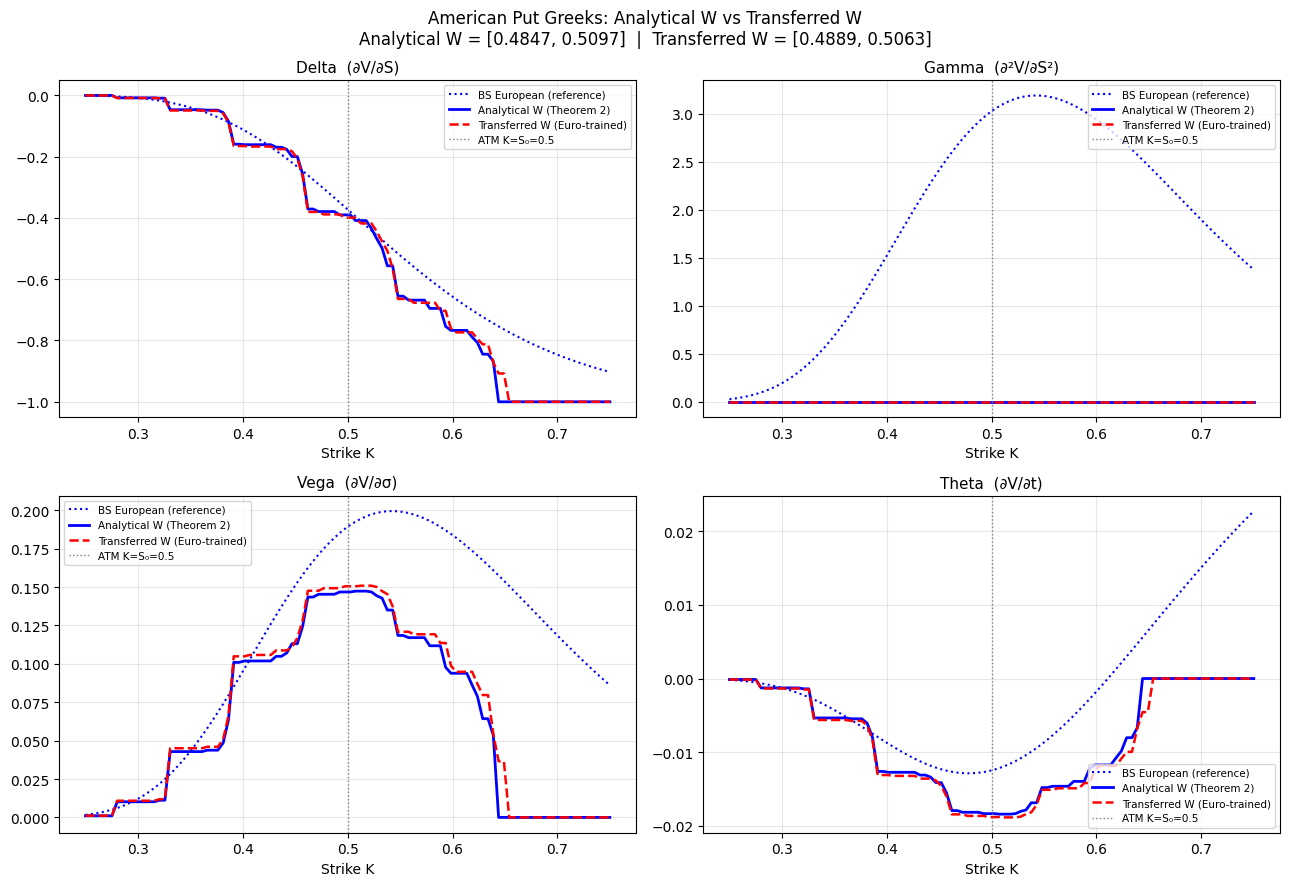

In [13]:
plot_american_greeks_transfer(
    K_test,
    greeks_analytical_W,
    greeks_transfer_W,
    greeks_bs,
    S0=S0,
    W_analytical=W_analytical,
    W_transfer=W_transfer,
)

### Plot: Absolute differences |analytical W − transferred W|

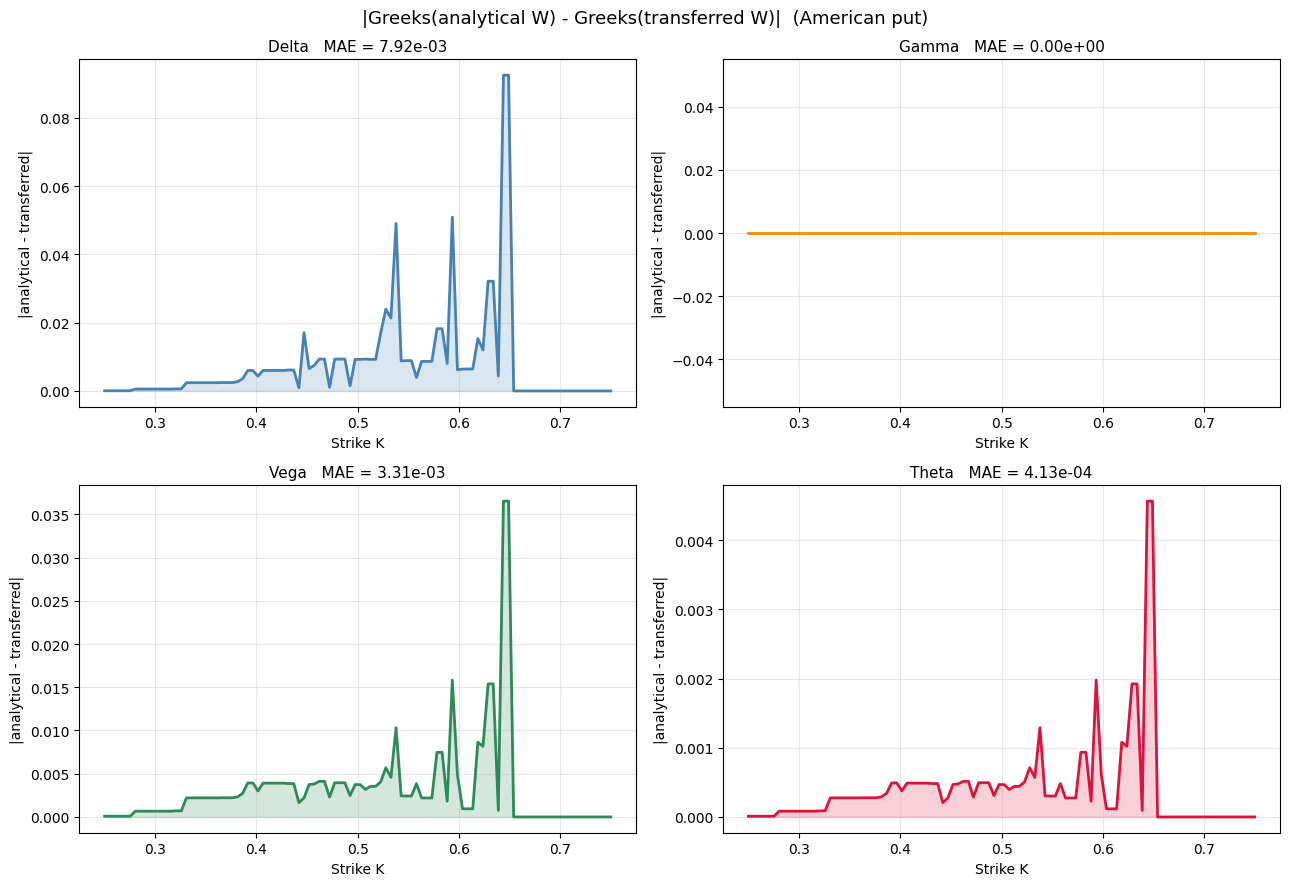

In [14]:
plot_american_greeks_transfer_errors(
    K_test,
    greeks_analytical_W,
    greeks_transfer_W,
)

### Interpretation

The W vectors differ by only ~0.004 per component (≈ 0.8%), yet the Greeks diverge noticeably:

| Greek | Effect of wrong W |
|-------|-------------------|
| **Delta** | Slightly more negative for transferred W — the wrong discounting puts more weight on lower stock-price nodes |
| **Gamma** | Both = 0 (piecewise-linear model regardless of W) |
| **Vega**  | Transferred W amplifies Vega near ATM: without the σ → W correction channel, the model over-attributes price sensitivity to volatility |
| **Theta** | Small shift; transferred W gives marginally larger absolute Theta |

**Why the indirect channel matters for Vega and Theta:**  
In the analytical model, W depends on σ (through the risk-neutral probabilities
`π_u = (exp(r·dt) − d)/(u − d)`). When computing `∂V/∂σ`, there are two paths:
1. Direct: σ changes the stock-price tree (u, d) → terminal/intrinsic payoffs change.
2. Indirect: σ changes u, d → risk-neutral probabilities change → W changes.

With a *fixed* W (transferred model), only path (1) exists.
This missing feedback makes the transferred model's Vega and Theta structurally incomplete —
not just numerically inaccurate.

**Conclusion:** Transferring W from European training not only degrades pricing accuracy
(Section 7) but also corrupts the Greeks.  The analytical initialisation from Theorem 2
is the correct starting point for both pricing and risk management.


## 9. ONNX Export

Export both models to ONNX format for graph visualisation with [Netron](https://netron.app/) and for inclusion in the VKR appendix.

| File | Architecture | Weights |
|---|---|---|
| `btnet_european.onnx` | BTNetEuropean | Trained (Adam) |
| `btnet_american_analytical.onnx` | BTNetAmerican | Analytical CRR |
| `btnet_american_transfer.onnx` | BTNetAmerican | Transferred from European |

In [15]:
import os

ONNX_DIR = "onnx_exports"
os.makedirs(ONNX_DIR, exist_ok=True)

# Representative input: single strike at ATM (batch_size=1)
dummy_K = torch.tensor([[S0]], dtype=torch.float32)

# ── BTNetEuropean ──────────────────────────────────────────────────────────
model_european.eval()
path_eu = os.path.join(ONNX_DIR, "btnet_european.onnx")
torch.onnx.export(
    model_european,
    dummy_K,
    path_eu,
    input_names=["strike"],
    output_names=["price"],
    dynamic_axes={"strike": {0: "batch_size"}, "price": {0: "batch_size"}},
    opset_version=17,
)
print(f"Exported BTNetEuropean            → {path_eu}")

# ── BTNetAmerican (analytical CRR weights) ──────────────────────────────────
model_amer_analytical.eval()
path_am_an = os.path.join(ONNX_DIR, "btnet_american_analytical.onnx")
torch.onnx.export(
    model_amer_analytical,
    dummy_K,
    path_am_an,
    input_names=["strike"],
    output_names=["price"],
    dynamic_axes={"strike": {0: "batch_size"}, "price": {0: "batch_size"}},
    opset_version=17,
)
print(f"Exported BTNetAmerican (analytical) → {path_am_an}")

# ── BTNetAmerican (transferred weights from European) ───────────────────────
model_amer_transfer.eval()
path_am_tr = os.path.join(ONNX_DIR, "btnet_american_transfer.onnx")
torch.onnx.export(
    model_amer_transfer,
    dummy_K,
    path_am_tr,
    input_names=["strike"],
    output_names=["price"],
    dynamic_axes={"strike": {0: "batch_size"}, "price": {0: "batch_size"}},
    opset_version=17,
)
print(f"Exported BTNetAmerican (transfer)   → {path_am_tr}")

/var/folders/ym/22fx55fn2txc2hplzs04sfsm0000gp/T/ipykernel_57744/946681065.py:12: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0425 23:37:41.749000 57744 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0425 23:37:42.081000 57744 torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::nms
W0425 23:37:42.082000 57744 torch/onnx/_int

[torch.onnx] Obtain model graph for `BTNetEuropean([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `BTNetEuropean([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).
/var/folders/ym/22fx55fn2txc2hplzs04sfsm0000gp/T/ipykernel_57744/946681065.py:26: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0425 23:37:42.539000 57744 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may n

[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Exported BTNetEuropean            → onnx_exports/btnet_european.onnx
[torch.onnx] Obtain model graph for `BTNetAmerican([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `BTNetAmerican([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).
/var/folders/ym/22fx55fn2txc2hplzs04sfsm0000gp/T/ipykernel_57744/946681065.py:40: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0425 23:37:43.102000 57744 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may n

[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Exported BTNetAmerican (analytical) → onnx_exports/btnet_american_analytical.onnx
[torch.onnx] Obtain model graph for `BTNetAmerican([...]` with `torch.export.export(..., strict=False)`...


/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).


[torch.onnx] Obtain model graph for `BTNetAmerican([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Exported BTNetAmerican (transfer)   → onnx_exports/btnet_american_transfer.onnx


In [16]:
# Verify exported files
print(f"{'File':<45} {'Size':>8}")
print("-" * 55)
for fname in sorted(os.listdir(ONNX_DIR)):
    path = os.path.join(ONNX_DIR, fname)
    size_kb = os.path.getsize(path) / 1024
    print(f"  {fname:<43} {size_kb:6.1f} KB")

File                                              Size
-------------------------------------------------------
  btnet_american_analytical.onnx                 9.5 KB
  btnet_american_analytical.onnx.data            0.0 KB
  btnet_american_transfer.onnx                   9.5 KB
  btnet_american_transfer.onnx.data              0.0 KB
  btnet_european.onnx                            5.0 KB
  btnet_european.onnx.data                       0.0 KB
